### 11. Using a real dataset (Breast Cancer Wisconsin or similar):
#### a. Train Naive Bayes and Logistic Regression models.
#### b. Evaluate probability calibration using reliability diagrams and Brier score.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss


In [2]:
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [3]:
nb = GaussianNB()
nb.fit(X_train, y_train)
proba_nb = nb.predict_proba(X_test)[:, 1]


In [4]:
lr = LogisticRegression(max_iter=500)
lr.fit(X_train, y_train)
proba_lr = lr.predict_proba(X_test)[:, 1]


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [5]:
prob_true_nb, prob_pred_nb = calibration_curve(
    y_test, proba_nb, n_bins=10
)

prob_true_lr, prob_pred_lr = calibration_curve(
    y_test, proba_lr, n_bins=10
)


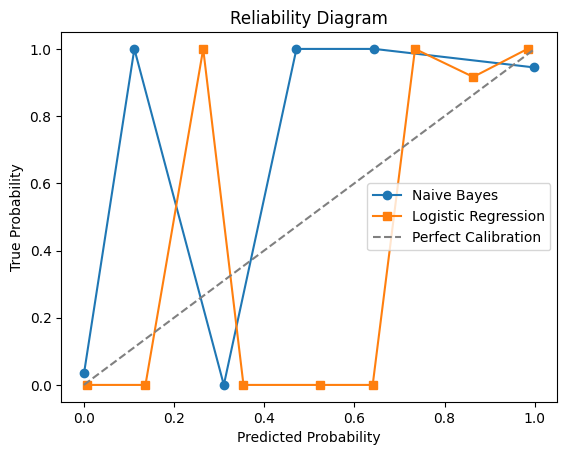

In [6]:
plt.plot(prob_pred_nb, prob_true_nb, marker='o', label="Naive Bayes")
plt.plot(prob_pred_lr, prob_true_lr, marker='s', label="Logistic Regression")
plt.plot([0,1], [0,1], linestyle='--', color='gray', label="Perfect Calibration")
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Reliability Diagram")
plt.legend()
plt.show()


In [7]:
brier_nb = brier_score_loss(y_test, proba_nb)
brier_lr = brier_score_loss(y_test, proba_lr)

print("Naive Bayes Brier Score:", brier_nb)
print("Logistic Regression Brier Score:", brier_lr)


Naive Bayes Brier Score: 0.05263502620706795
Logistic Regression Brier Score: 0.0203305446758297


On the Breast Cancer Wisconsin dataset, Logistic Regression demonstrates superior probability calibration compared to Naive Bayes, as evidenced by reliability diagrams and lower Brier scores. While Naive Bayes may achieve competitive accuracy, its strong independence assumptions lead to overconfident and miscalibrated probability estimates. Logistic Regression, by directly modeling conditional probabilities, provides more reliable uncertainty estimates, which is critical in medical decision-making.